In [13]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from transformers import BertTokenizer, BertModel
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import umap
import seaborn as sns

In [10]:
df = pd.read_csv('train/expanded_full.csv')

# PCA

In [21]:
model = GaussianMixture(n_components=2, random_state=42)
pca = PCA(n_components=2, random_state=42)

In [2]:
embeddings = np.load('train/bert_embeddings_expanded_full.npy')

In [22]:
downsized_embeddings = pca.fit_transform(embeddings)

In [ ]:
model.fit(embeddings)

GaussianMixture(n_components=2, random_state=42)

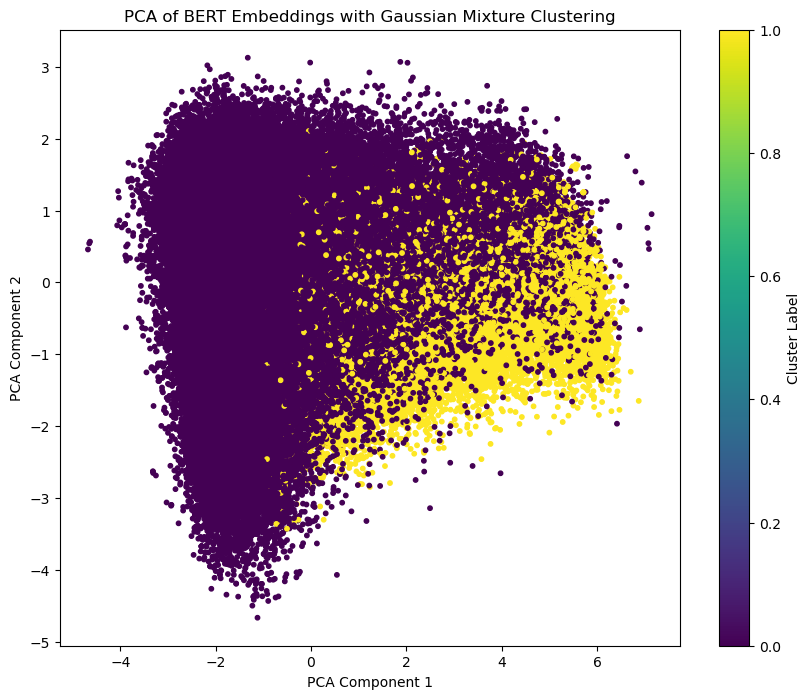

In [29]:
plt.figure(figsize=(10, 8))
plt.scatter(downsized_embeddings[:, 0], downsized_embeddings[:, 1], c=model.predict(embeddings), cmap='viridis', s=10)
plt.title('PCA of BERT Embeddings with Gaussian Mixture Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

# UMAP

In [3]:
scaled_embeddings = StandardScaler().fit_transform(embeddings)

In [16]:
umap_model = umap.UMAP(metric="cosine", n_neighbors=15, min_dist=0.3, random_state=42)
umap_2d = umap_model.fit_transform(scaled_embeddings)

/opt/anaconda3/envs/diss/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/diss/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


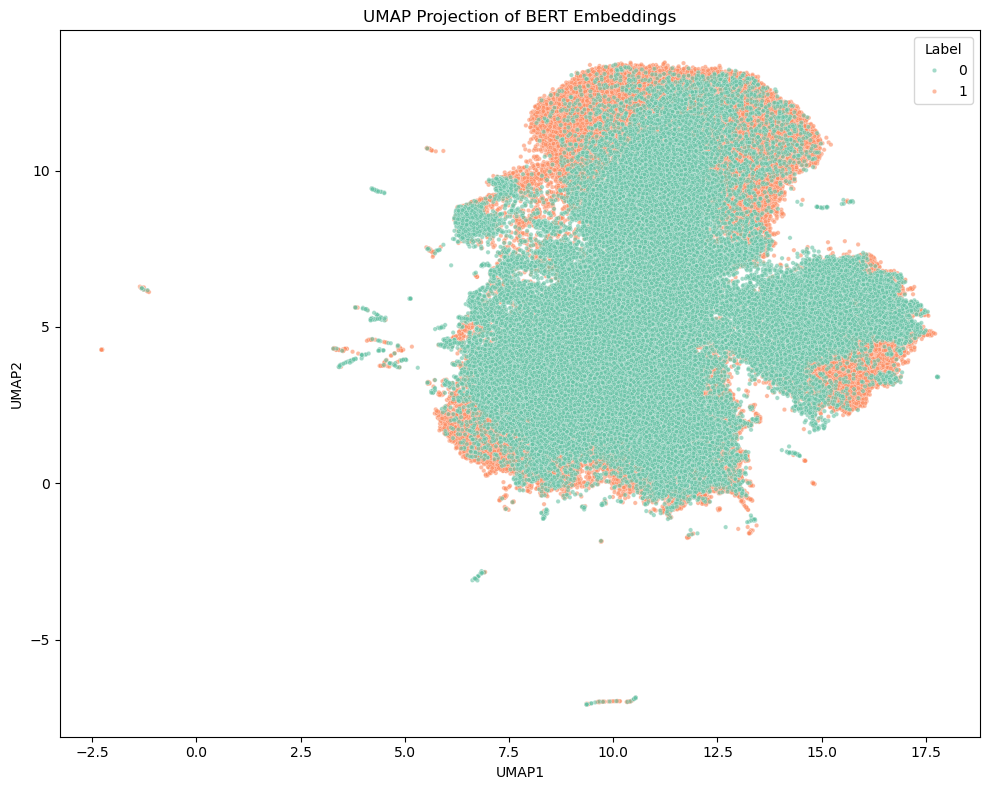

In [17]:
df_umap = pd.DataFrame(umap_2d, columns=["UMAP1", "UMAP2"])
df_umap["label"] = df["label"].values
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2", hue="label", palette="Set2", s=10, alpha=0.6)
plt.title("UMAP Projection of BERT Embeddings")
plt.legend(title="Label", loc="best")
plt.tight_layout()
plt.show()